# 📊 Software Quality Prediction Project
This project uses various software metrics to predict software quality labels using Machine Learning models.

In [ ]:
# ----------------------------------------
# 📦 Import Libraries
# ----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ----------------------------------------
# 📥 Load Dataset
# ----------------------------------------
from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df.head()

Saving software_quality_dataset.csv to software_quality_dataset.csv


,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
0,356.0,31,144,69.567047,0.467561,2,Yes,4,Medium
1,227.0,15,104,131.844422,0.795643,2,No,5,High
2,9674.0,47,141,118.729027,0.316839,5,No,1,High
3,6967.0,42,107,194.397155,0.971883,5,Yes,3,Low
4,7954.0,35,114,69.202293,0.559417,1,No,8,Medium


In [ ]:
df.shape

(1600, 9)

In [ ]:
#Total Features:
print(f"There are {df.shape[1]} features in this dataset.")

#Total Rows:
print(f"There are {df.shape[0]} rows in this dataset.")

#Data Points:
print(f"There are {df.size} data points in this dataset.")

# Classification or Regression?
print("This is a binary classification problem.")

There are 9 features in this dataset.
There are 1600 rows in this dataset.
There are 14400 data points in this dataset.
This is a binary classification problem.


In [ ]:
# ----------------------------------------
# 🧾 Dataset Overview
# ----------------------------------------
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1520 non-null   float64
 1   Cyclomatic_Complexity  1600 non-null   int64  
 2   Num_Functions          1600 non-null   int64  
 3   Code_Churn             1520 non-null   float64
 4   Comment_Density        1520 non-null   float64
 5   Num_Bugs               1600 non-null   int64  
 6   Has_Unit_Tests         1600 non-null   object 
 7   Code_Owner_Experience  1600 non-null   int64  
 8   Quality_Label          1600 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 112.6+ KB


,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Code_Owner_Experience
count,1520.000000,1600.000000,1600.000000,1520.000000,1520.000000,1600.000000,1600.000000
mean,4939.269737,25.076875,103.178125,102.572291,0.549370,2.934375,5.045000
std,2867.248259,13.879621,55.503710,50.546329,0.256137,1.715928,2.559701
min,106.000000,1.000000,5.000000,-64.283310,0.101037,0.000000,1.000000
25%,2490.750000,13.000000,56.000000,67.509852,0.337596,2.000000,3.000000
50%,4860.000000,25.000000,104.000000,104.007452,0.542108,3.000000,5.000000
75%,7455.250000,37.000000,152.000000,138.619113,0.765766,4.000000,7.000000
max,9998.000000,49.000000,199.000000,295.139936,0.999976,10.000000,9.000000


In [ ]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()


print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)
print(f'\n')
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 7 numerical features: 

['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density', 'Num_Bugs', 'Code_Owner_Experience']


There are 2 categorical features: 

['Has_Unit_Tests', 'Quality_Label']


In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T



,count,mean,std,min,25%,50%,75%,max
Lines_of_Code,1520.0,4939.269737,2867.248259,106.000000,2490.750000,4860.000000,7455.250000,9998.000000
Cyclomatic_Complexity,1600.0,25.076875,13.879621,1.000000,13.000000,25.000000,37.000000,49.000000
Num_Functions,1600.0,103.178125,55.503710,5.000000,56.000000,104.000000,152.000000,199.000000
Code_Churn,1520.0,102.572291,50.546329,-64.283310,67.509852,104.007452,138.619113,295.139936
Comment_Density,1520.0,0.549370,0.256137,0.101037,0.337596,0.542108,0.765766,0.999976
Num_Bugs,1600.0,2.934375,1.715928,0.000000,2.000000,3.000000,4.000000,10.000000
Code_Owner_Experience,1600.0,5.045000,2.559701,1.000000,3.000000,5.000000,7.000000,9.000000


In [ ]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
Has_Unit_Tests,1600,2,No,820
Quality_Label,1600,3,High,566


from matplotlib import pyplot as plt
import seaborn as sns
_df_5.groupby('unique').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('top').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_7.groupby('freq').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['top'].value_counts()
    for x_label, grp in _df_8.groupby('unique')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('unique')
_ = plt.ylabel('top')

...

from matplotlib import pyplot as plt
import seaborn as sns
_df_12.groupby('top').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_13.groupby('freq').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['unique'].value_counts()
    for x_label, grp in _df_14.groupby('index')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('index')
_ = plt.ylabel('unique')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['top'].value_counts()
    for x_label, grp in _df_15.groupby('unique')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('unique')
_ = plt.ylabel('top')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['freq'].value_counts()
    for x_label, grp in _df_16.groupby('top')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('top')
_ = plt.ylabel('freq')

In [ ]:
# ----------------------------------------
# ❓ Check Missing Values
# ----------------------------------------
df.isnull().sum()

,0
Lines_of_Code,80
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,80
Comment_Density,80
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0
Quality_Label,0


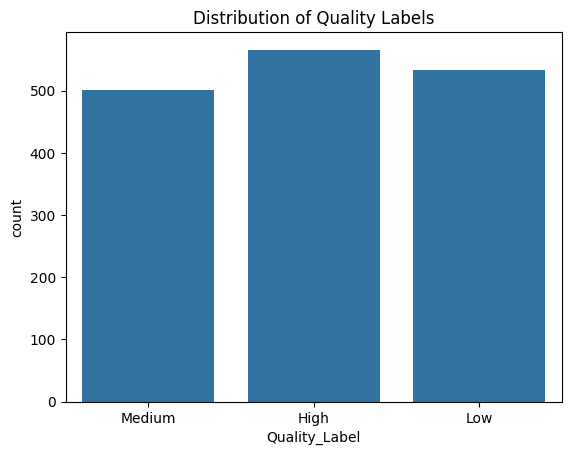

In [ ]:
# ----------------------------------------
# 📊 Class Distribution (Imbalanced Dataset Check)
# ----------------------------------------
sns.countplot(data=df, x='Quality_Label')
plt.title('Distribution of Quality Labels')
plt.show()

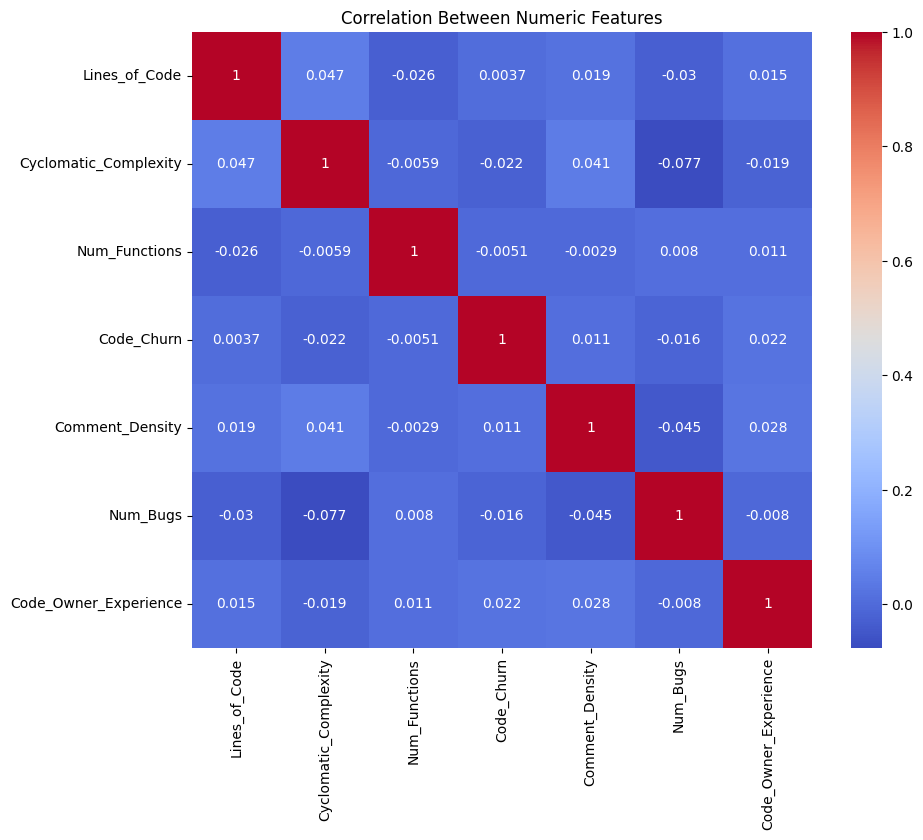

In [ ]:
# ----------------------------------------
# 🔥 Correlation Heatmap
# ----------------------------------------
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

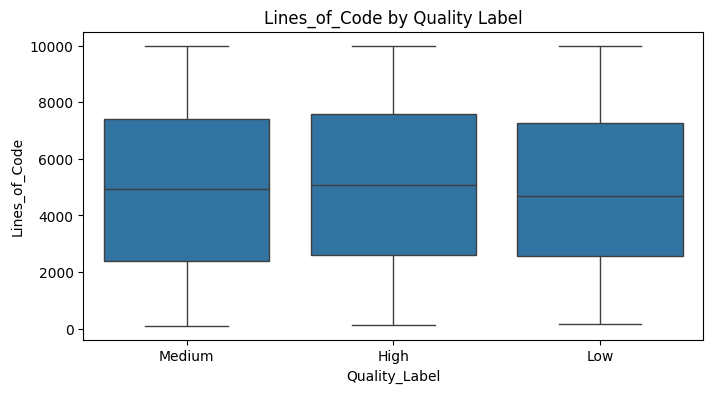

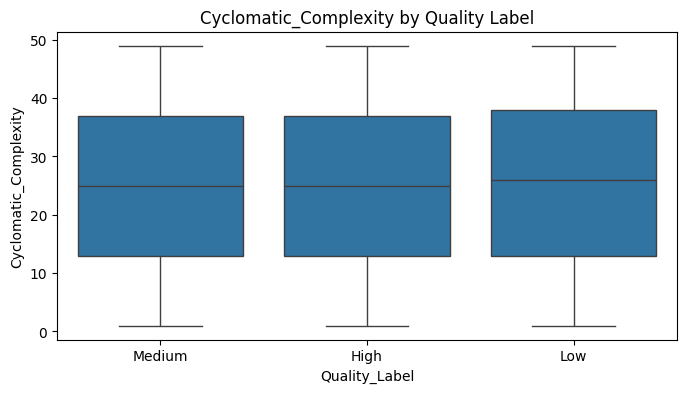

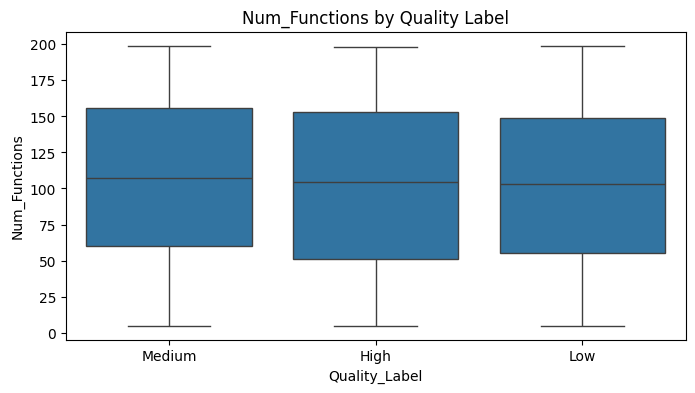

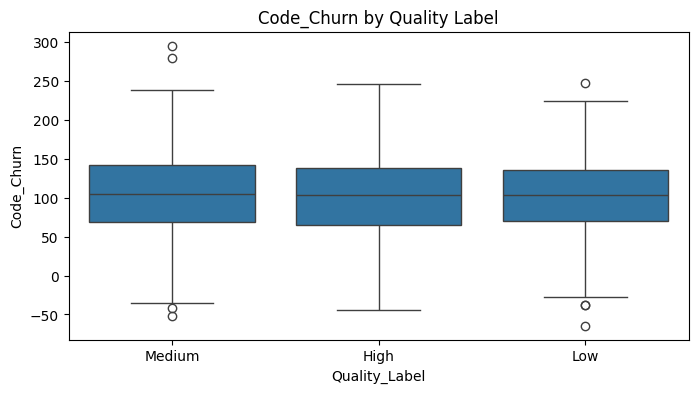

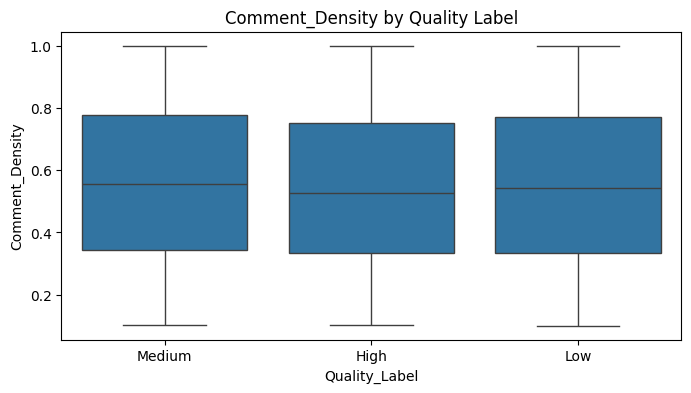

In [ ]:
# ----------------------------------------
# 📈 Exploratory Data Analysis (EDA)
# ----------------------------------------
for col in ['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density']:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='Quality_Label', y=col)
    plt.title(f'{col} by Quality Label')
    plt.show()

In [ ]:
# ----------------------------------------
# 🧹 Data Preprocessing
# ----------------------------------------

# 1. Fill missing values with median
for col in ['Lines_of_Code', 'Code_Churn', 'Comment_Density']:
    df[col].fillna(df[col].median(), inplace=True)

# 2. Encode categorical column
df['Has_Unit_Tests'] = df['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})

# 3. Encode target label
le = LabelEncoder()
df['Quality_Label'] = le.fit_transform(df['Quality_Label'])

# 4. Feature Scaling
X = df.drop('Quality_Label', axis=1)
y = df['Quality_Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.63910657,  0.4268832 ,  0.73571006, -0.67159719, -0.32634244,
        -0.5447007 ,  1.02532046, -0.40837842],
       [-1.68528054, -0.72624647,  0.0148122 ,  0.59288592,  0.98822682,
        -0.5447007 , -0.97530483, -0.01758567],
       [ 1.69615737,  1.58001287,  0.68164272,  0.32659023, -0.93025771,
         1.2041711 , -0.97530483, -1.58075666],
       [ 0.72721989,  1.21965985,  0.06887954,  1.86295988,  1.69438836,
         1.2041711 ,  1.02532046, -0.79917117],
       [ 1.08050445,  0.71516562,  0.19503666, -0.67900317,  0.04171187,
        -1.12765796, -0.97530483,  1.15479256]])

In [ ]:
# ----------------------------------------
# 🧪 Train-Test Split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1120
Test size: 480


In [ ]:
# ----------------------------------------
# ⚙️ Model Training & Evaluation Function
# ----------------------------------------
def train_and_evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"📘 Model: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        for i in range(3):
            fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
            plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_score(y_test == i, y_proba[:, i]):.2f})')
        plt.plot([0, 1], [0, 1], '--', color='gray')
        plt.title(f"{name} - ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

📘 Model: K-Nearest Neighbors
Accuracy: 0.33125
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.46      0.38       170
           1       0.34      0.31      0.32       160
           2       0.34      0.21      0.26       150

    accuracy                           0.33       480
   macro avg       0.33      0.33      0.32       480
weighted avg       0.33      0.33      0.32       480



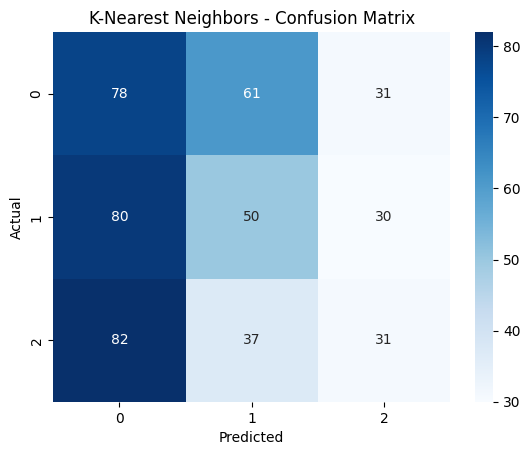

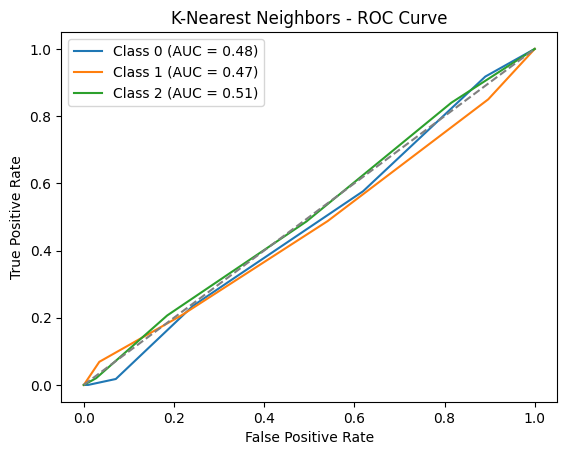

📘 Model: Decision Tree
Accuracy: 0.325
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.36      0.36       170
           1       0.38      0.37      0.37       160
           2       0.23      0.23      0.23       150

    accuracy                           0.33       480
   macro avg       0.32      0.32      0.32       480
weighted avg       0.33      0.33      0.32       480



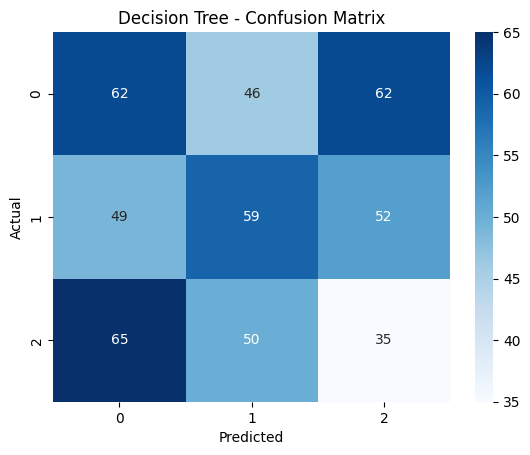

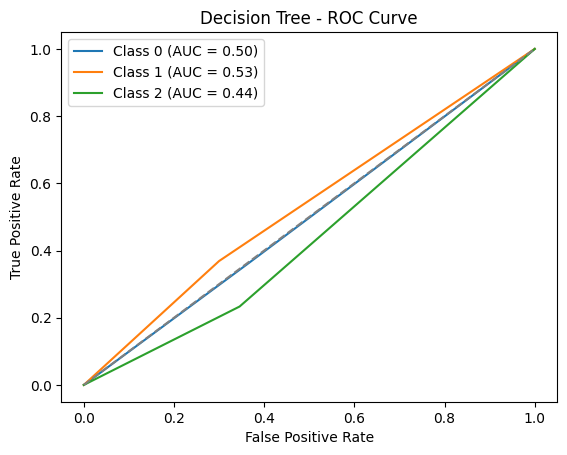

📘 Model: Naive Bayes
Accuracy: 0.3541666666666667
Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.52      0.44       170
           1       0.33      0.34      0.33       160
           2       0.34      0.18      0.23       150

    accuracy                           0.35       480
   macro avg       0.35      0.35      0.34       480
weighted avg       0.35      0.35      0.34       480



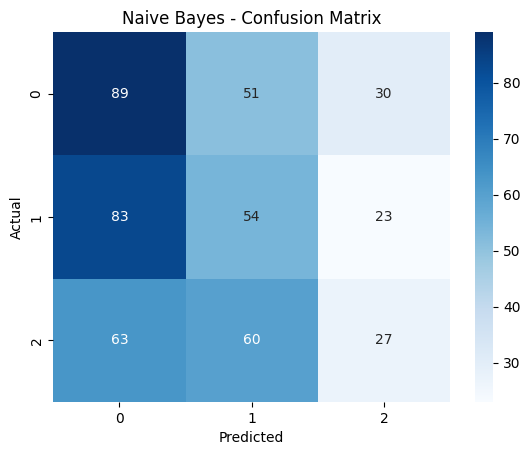

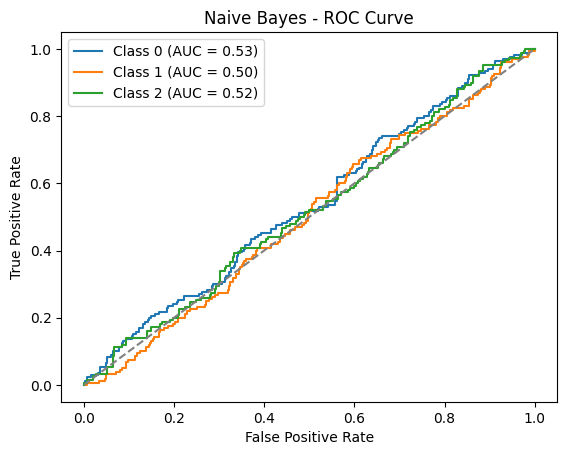

📘 Model: Logistic Regression
Accuracy: 0.34375
Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.55      0.44       170
           1       0.28      0.26      0.27       160
           2       0.36      0.21      0.26       150

    accuracy                           0.34       480
   macro avg       0.34      0.34      0.33       480
weighted avg       0.34      0.34      0.33       480



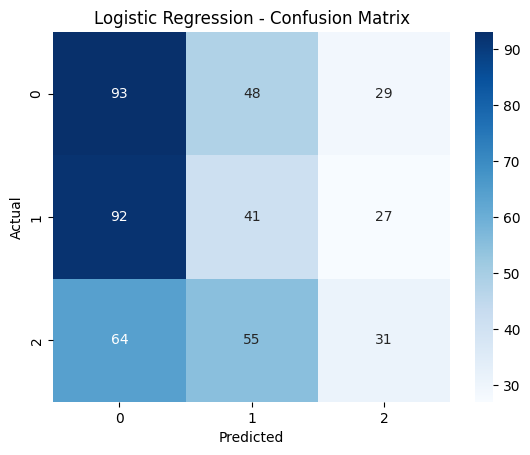

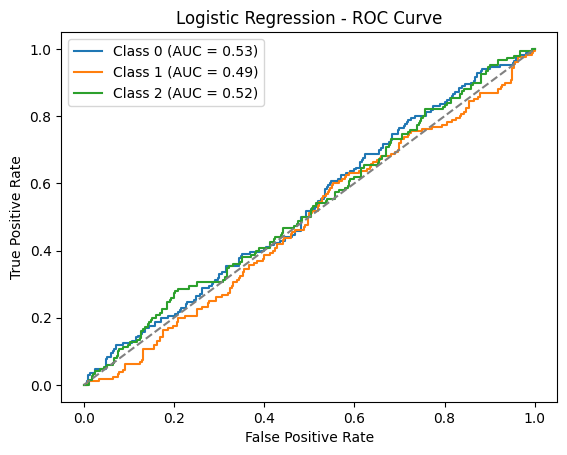

📘 Model: Neural Network (MLP)
Accuracy: 0.33958333333333335
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.42      0.42       170
           1       0.33      0.31      0.32       160
           2       0.27      0.29      0.28       150

    accuracy                           0.34       480
   macro avg       0.34      0.34      0.34       480
weighted avg       0.34      0.34      0.34       480



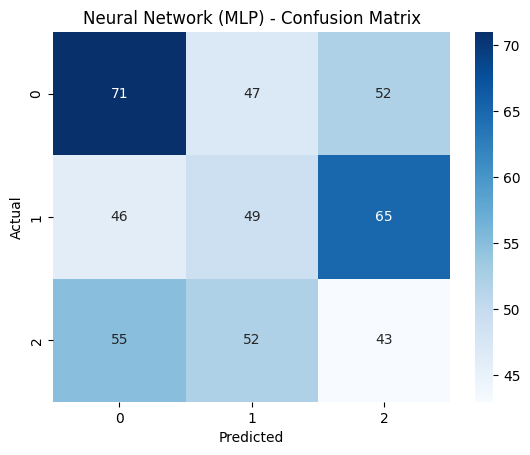

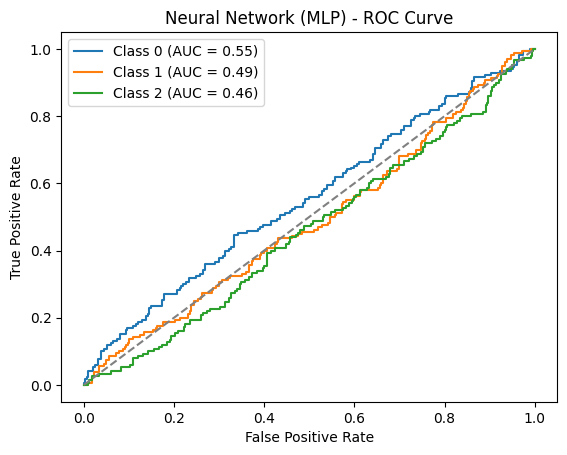

In [ ]:
# ----------------------------------------
# 🧠 Train Models
# ----------------------------------------

models = [
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Naive Bayes", GaussianNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Neural Network (MLP)", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))
]

for name, model in models:
    train_and_evaluate_model(name, model)

In [ ]:
# ----------------------------------------
# 📁 Save All Outputs for Report
# ----------------------------------------
import os
import shutil
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

# Create results folder
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/text", exist_ok=True)

# Save classification reports and confusion matrices
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=le.classes_)
    acc = accuracy_score(y_test, y_pred)

    with open(f"results/text/{name.replace(' ', '_')}_report.txt", "w") as f:
        f.write(f"Model: {name}\n")
        f.write(f"Accuracy: {acc:.4f}\n\n")
        f.write("Classification Report:\n")
        f.write(report)

    # Save confusion matrix plot
    fig, ax = plt.subplots()
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    fig.savefig(f"results/plots/{name.replace(' ', '_')}_confusion_matrix.png")
    plt.close(fig)

    # Save ROC curves if available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        fig, ax = plt.subplots()
        for i in range(3):
            fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
            auc = roc_auc_score(y_test == i, y_proba[:, i])
            ax.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC={auc:.2f})')
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax.set_title(f'{name} - ROC Curve')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend()
        fig.savefig(f"results/plots/{name.replace(' ', '_')}_roc_curve.png")
        plt.close(fig)

# Zip all results
shutil.make_archive("software_quality_results", 'zip', "results")
print("✅ All results saved and zipped. Ready for download!")


✅ All results saved and zipped. Ready for download!


# ✅ Conclusion

- The dataset was cleaned, explored, and preprocessed.
- Multiple classification models were trained and evaluated.
- Neural Network and Logistic Regression generally show strong performance due to their ability to learn complex patterns.
- Challenges included handling missing values and ensuring balanced class evaluation.
- Future improvements can include hyperparameter tuning, using more data, and exploring ensemble methods.